In [1]:
import msprime 
import dpluspy 
import numpy as np
import pickle
import demes

In [2]:
replicates = []
for rep in range(100):
    with open(f"stats/control_rep_{rep}_stats.pkl", "rb") as fin:
        replicates.append(pickle.load(fin))

bins = np.logspace(-6, -2, 17) 
pop_ids = ["PopX", "PopY"]

In [3]:
model = dpluspy.inference.compute_bin_stats(
    "graph.yaml", bins=bins, u=1.1525e-8, sampled_demes=pop_ids)

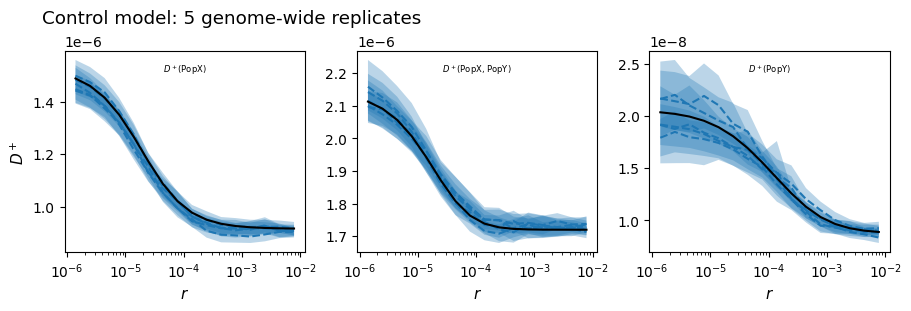

In [11]:
dpluspy.plotting.plot_D_plus_curves(
    means=[replicates[i]["means"] for i in range(5)],
    varcovs=[replicates[i]["varcovs"] for i in range(5)],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue"] * 5 + ["black"],
    out="figures/figure_1.pdf",
    title="Control model: 5 genome-wide replicates",
    labels=None
)

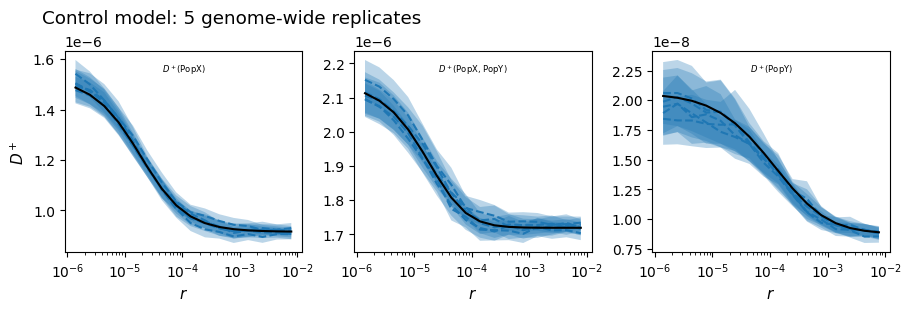

In [12]:
dpluspy.plotting.plot_D_plus_curves(
    means=[replicates[i]["means"] for i in range(5, 10)],
    varcovs=[replicates[i]["varcovs"] for i in range(5, 10)],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue"] * 5 + ["black"],
    out="figures/figure_2.pdf",
    title="Control model: 5 genome-wide replicates",
    labels=None
)

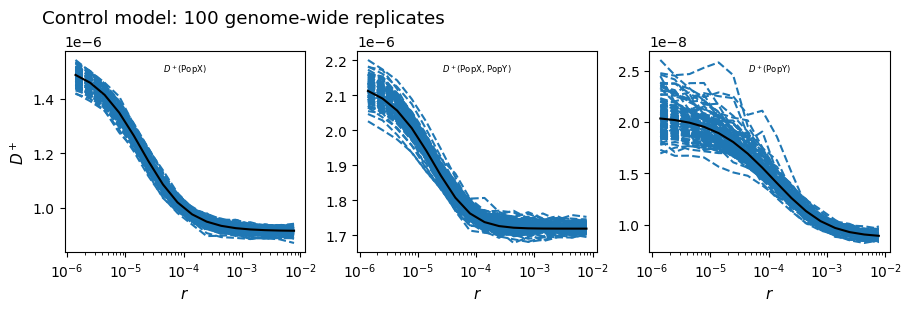

In [13]:
fake_varcovs = [[v * 0 for v in replicates[0]["varcovs"]]]
dpluspy.plotting.plot_D_plus_curves(
    means=[replicates[i]["means"] for i in range(100)],
    varcovs=fake_varcovs * 100,
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue"] * 100 + ["black"],
    out="figures/figure_3.pdf",
    labels=None,
    title="Control model: 100 genome-wide replicates"
)

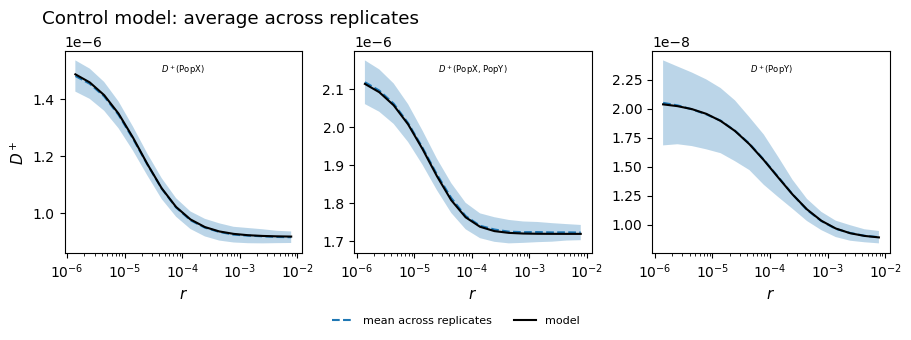

In [14]:
agg_means_arr = np.mean([replicates[i]["means"] for i in range(100)], axis=0)
agg_means = [x for x in agg_means_arr]
agg_varcovs_arr = np.mean([replicates[i]["varcovs"] for i in range(100)], axis=0)
agg_varcovs = [x for x in agg_varcovs_arr]

dpluspy.plotting.plot_D_plus_curves(
    means=agg_means,
    varcovs=agg_varcovs,
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue"] + ["black"],
    labels=["mean across replicates"] + ["model"],
    out="figures/figure_4.pdf",
    title="Control model: average across replicates"
)

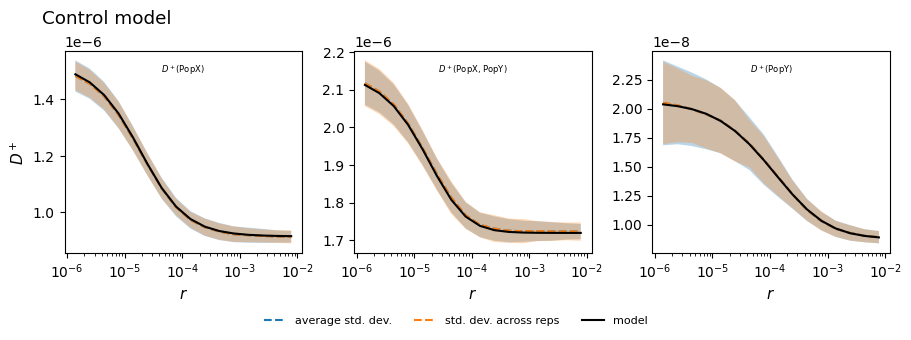

In [16]:
# plot the variance across runs
replicate_stddvs = np.std([replicates[i]["means"] for i in range(100)], axis=0) ** 2

replicate_varcovs = []
for stddvs in replicate_stddvs:
    arr = np.zeros((3, 3))
    arr[[0, 1, 2], [0, 1, 2]] = stddvs
    replicate_varcovs.append(arr)

dpluspy.plotting.plot_D_plus_curves(
    means=[agg_means, agg_means],
    varcovs=[agg_varcovs, replicate_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue", "tab:orange", "black"],
    out="figures/figure_5.pdf",
    title="Control model",
    labels=["average std. dev.", "std. dev. across reps", "model"]
)